# Example XX - Complete PRMS Setup for Upper Yellowstone Basin with no lakes

## Constructing an unstructured PRMS model of the Upper Yellowstone River

In [1]:
import os
from pathlib import Path
import json
import warnings
import inspect
from typing import Union, Optional

import dany
import flopy
import geopandas as gpd
import pandas as pd
import rasterio as rio
import rioxarray
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from flopy.utils.triangle import Triangle
from flopy.utils.voronoi import VoronoiGrid
from flopy.discretization import VertexGrid as FlopyVertexGrid
import GRIDtools as gt
from gsflow.prms import ParameterRecord, PrmsData
from gsflow import PrmsParameters as pygsflowparams
import gsflow.builder.builder_utils as bu
from shapely.geometry import Polygon
from chmdata import GridMet, BBox

In [2]:
src_root = (Path('..') / 'src').resolve()
os.chdir(src_root)

from mihms.prep.utils import clip_raster, load_raster_window, check_precip_string, check_min_temp_string, check_max_temp_string, write_prms_datafile
from mihms.config import project_root, prep
from mihms.prep import prms as pprms
from mihms.utils.io import user_warning

In [3]:
out_pth = Path(os.getcwd()).parent / 'example/Yellowstone'

## Set Up Spatial Data
Set Input Paths

In [4]:
mt_elev_pth = Path(r'D:\Spatial_Data\Statewide_Data\Raster\SRTM_Elevation\MT_hydro_SRTM_30m.tif')
uy_basin_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\UYBoundary_abv_Shields_5071.shp')
uy_prms_segs = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\uy_prms_segs.shp')
yl_lake = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\yellowstone_lake.shp')
pourpnts_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\Vector\prms_subbasin_pourpnts.shp')

In [5]:
clp_elev_pth = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\MT_hydro_SRTM_30m_clipped.tif')

Load a windowed dataset (using basin shape bounds) from statewide Elevation raster.

In [6]:
geom = gpd.read_file(uy_basin_pth)
w = load_raster_window(geom, clp_elev_pth)

Initialize a flopy Raster Class with the returned raster metadata.

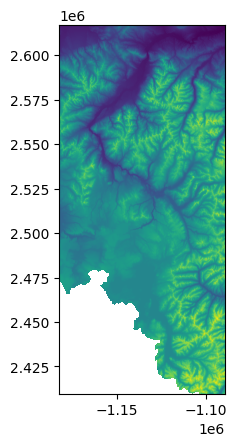

<Axes: >

In [7]:
rstr = flopy.utils.Raster(
    array=w['array'],
    bands=w['bands'],
    crs=w['crs'],
    transform=w['transform'],
    nodataval=w['nodata'],
    driver=w['driver']
)
rstr.plot()

Load vector geometry data that defines the model domain.

In [8]:
basin = gpd.read_file(uy_basin_pth)
streams = gpd.read_file(uy_prms_segs)
streams = streams.to_crs(5071)

c:\Users\CNB968\.conda\envs\prms\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(
c:\Users\CNB968\.conda\envs\prms\lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


Plot the geometry data that makes up the model domain.

<Axes: >

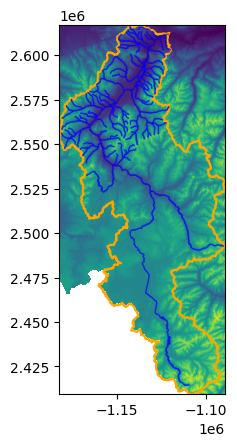

In [9]:
ax = plt.axes()
rstr.plot(ax=ax)
basin.plot(ax=ax, facecolor="None", edgecolor='orange', lw=1.5)
streams.plot(ax=ax, edgecolor='blue', lw=1, alpha=0.75)

## Triangular Mesh & Voronoi Grid with flopy

In [10]:
tg = pprms.voronoi_grid_from_hydrography(
    basin_geom=basin,
    base_res=3000,
    strm_geom=streams,
    strm_res=200,
    strm_buff=3,
    simp_basin=7,
    simp_strms=1
)

Input streams have more than one geometry, dissolving geometries...


Plot the triangle grid.

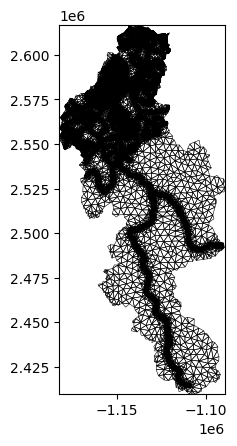

In [11]:
tg[1].plot(lw=0.4)

Save the PRMSvertexgrid object as a .grid file (it's just a json with different file extension).

In [12]:
tg[0].save_grid('UY_voronoi_nolakes_grid', out_pth.resolve())

## Condition or correct Elevation data to grid

For this case, manually editing the DEM was necessary to try and match NHD flowlines (primarily for semi-accurate subbasin delineation)

Initialize a Cascades Object using the saved grid json. For use in the MIHMS package, these are jsons with a file extension of .grid.

In [13]:
cascparams = pprms.PRMSCascades(out_pth / 'UY_voronoi_nolakes_grid.grid')

params.py:137: UserWarning: There are no parameters specified yet and or no nhru dimension to check grid. Assigning grid anyway, make sure to check any inserted parameters match the grid size.


By default, the ```PRMSCascades``` object will assign HRU type = 1 for the model grid. In this example, with only basin and stream geometries (no lakes) we just accept these defaults.

Now we will use the ```PPRMSCascades.streams_from_hydrography()``` function with input NHD stream segments to assign stream lines to the grid. Here we use the argument segment_ids=True which treats each NHD segment as a segment in the model.

In [17]:
cascparams.streams_from_hydrography(streams, segment_ids=True)

Now we will prepare the elevation data, by first getting the zonal statistics across the model grid from an input DEM. No data values are replaced by NaN's.

In [60]:
grd_elev = gt.calc_zonal_stats(cascparams.grid, clp_elev_pth, stats='min', all_touched=True)
dem = np.where(grd_elev.values.ravel() == rstr.nodatavals[0], np.nan, grd_elev.values.ravel())

C:\Users\CNB968\AppData\Local\Temp\ipykernel_21432\306004777.py:1: UserWarning: Not all geometries were returned, 15 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  grd_elev = gt.calc_zonal_stats(cascparams.grid, clp_elev_pth, stats='min', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


Next use the ```fill_voronoi_nan()``` function to fill all grid cells that did not have valid elevations mapped to them (usually only occurs on edges).

In [61]:
filled_dem = pprms.fill_voronoi_nan(dem, cascparams.grid)

Filling 75 missing grid cell values...


These grid cell elevations were manually adjusted to remove undeclared sinks along the basin boundary and force drainage paths to align to NHD flowlines for calibration subbasins.

In [62]:
# custom dem alteration to make sure Sixmile and Mill Cr line up for subbasin calculation
cepnts = {
    197: 2395,
    202: 2395,
    193: 2366,
    195: 2365,
    194: 2364,
    2147: 2960,
    2383: 2959,
    2781: 1339,
    1852: 1332.8,
    1853: 1335,
    2563: 1336,
    9: 1337,
    2228: 1339,
    1896: 1335.9,
    1653: 2839,
    2116: 2820,
    6106: 2980,
    1654: 2965,
    45950: 2363,
    1878: 2931,
    2116: 2900,
    1653: 2850,
    2178: 2840,
    1663: 1750,
    1883: 1740,
    2178: 2850,
    190: 2370,
    45960: 2361,
    191: 2367,
    192: 2366 
}

In [63]:
edit_dem = filled_dem.copy()
for k, i in cepnts.items():
    edit_dem[k] = i

Now that we are satisfied with the manually edited elevation values, we use the dany package dem conditioning methods to fill sinks and then calculate flow directions of the unstructured grid.

In [64]:
conditioned_dem = dany.fill_sinks(cascparams._flopygrid, edit_dem)

In [65]:
cascparams.map_flow_directions(conditioned_dem)

params.py:987: UserWarning: Elevation data was input as an argument but elevation data is already mapped to the grid, existing elevations will be overwritten


running dijkstra


params.py:360: UserWarning: The parameter already exists, overwriting the existing 'hru_area' parameter.
params.py:360: UserWarning: The parameter already exists, overwriting the existing 'hru_aspect' parameter.
params.py:360: UserWarning: The parameter already exists, overwriting the existing 'hru_slope' parameter.


Use the ```find_undeclared_sinks()``` function which is designed to work with Dany FlowDirections array. The basin outlet will always be counted as a sink so at a minimum this function returns 1 sink, which is what we want here. An output greater than 1 means there are unintentional sinks in the model grid that need to be corrected. This method was used to identify the sinks that were corrected in the previous steps.

In [66]:
snks = pprms.find_undeclared_sinks(cascparams.fdir.flow_direction_array)
cascparams.fdir.flow_direction_array[snks.astype(bool)].size

1

Map Subbasins for the model domain (these will be used to calibrate). The shapefile that is read in was created manually by selecting points that fall within the necessary model cell that is the outlet of each subbasin. This can be achieved by outputting the model grid using the export_cascades_grid() function of the PRMSCascades class (shown at the end of this section).

In [67]:
pourpnts = gpd.read_file(pourpnts_pth)

In [68]:
cascparams.map_subbasins(pourpnts)

In [106]:
cascparams.parameters

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                           ncascade: 90541, nmonths: 12, ntemp: 104,
                           nrain: 104, nssr: 46199, ngw: 46199, ndepl: 1,
                           ndeplval: 11)
Coordinates:
  * nrain                 (nrain) int32 0 1 2 3 4 5 6 ... 98 99 100 101 102 103
  * ndepl                 (ndepl) int32 1
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nmonths,
                                ntemp, nssr, ngw, ndeplval
Data variables: (12/108)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 2 17 2 17 17 16
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev              (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                    ...
    melt_look             (nhru) int32 90 90 90 90 90 90 ... 90 90 90 90 90 90
    settle_const          (nhru) float64 0.1 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1 0.1
    snarea_thresh         (nhru) float64 50.0 50.0 50.0 50.0 ... 50.0 50.0 50.0
    cecn_coef             (nmonths, nhru) float64 5.0 5.0 5.0 ... 5.0 5.0 5.0
    tstorm_mo             (nmonths, nhru) int32 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

Calculate the Cascade Links. This function has flexible inputs, here we did not need to include any because we already had elevations assigned, a stream grid delineated, and flow directions calculated for the cascparams PRMSCascades object.

In [69]:
cascparams.cascades_from_hydrography()

In this example we leaving out Yellowstone Lake. the ```mihms.prep.prms``` module has functions that assign default parameter values for various PRMS process modules. In this case we'll use the model output settings, and stream routing default methods (which are for Muskingum Routing).

In [70]:
pprms.set_output_options(cascparams)
pprms.routing_defaults(cascparams, cascparams.parameters['nsegment'].size)

For this model, if using Muskingum routing, we want to start with no attenuation. So, the x_coef paramter is adjusted to a value of 0.5 which means it basically is only a function of inflow.

In [72]:
cascparams.set_values('x_coef', np.ones(cascparams.parameters['nsegment'].size) * 0.5)

Check out the final set of physcial model domain parameters.

In [73]:
cascparams.parameters

<xarray.Dataset>
Dimensions:              (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                          ncascade: 90541)
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade
Data variables: (12/26)
    elev_units           (one) int32 1
    hru_type             (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin         (nhru) int32 19 19 19 19 19 19 19 ... 1 2 17 2 17 17 16
    hru_lat              (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon              (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev             (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                   ...
    print_type           (one) int32 1
    obsin_segment        (nsegment) int32 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    obsout_segment       (nsegment) int32 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    segment_flow_init    (nsegment) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    K_coef               (nsegment) float64 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    x_coef               (nsegment) float64 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5

The various model domain geometries can be exported to check for inaccuracies.

First we output the stream segment layer.

In [74]:
cascparams.export_stream_segments(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\prms_nolake_segments.shp'))

C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1355: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stm_out.to_file(filename)


Next, the model grid with some of the paramters as attributes. As well as some of the terrain analysis variables that aren't necessarily parameters.

In [105]:
cascparams.export_cascades_grid(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\UY_prms_nolakes_grid.shp'), 
                                ['hru_type', 'hru_subbasin', 'hru_elev'], 
                                flow_directions=True,
                                stream_grid=True, 
                                flow_accum=True)

C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1327: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  out.to_file(filename)


We can also export the cascade links to see how variables are routed through the model grid.

In [76]:
cascparams.export_hru_cascade_links(Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\UY_prms_nolakes_cascades.shp'))

C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1343: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  casgdf.to_file(filename)


Also we can save this parameter object for later use. We can save it as a PRMS file or (in this case) a .netcdf.

In [77]:
cascparams.parameters.to_netcdf(out_pth / 'UY_Domain_nolakes_Params.nc')

## Get Meteorology Inputs

Next, we will get meteorology input data from GridMET and structure it for use with our PRMS model.

Here we use MT-DNRC's chmdata package to get GridMET precip, minimum temperature, and maximum temperature.

In [78]:
basin_bounds = basin.to_crs(4326).bounds
met_bbox = BBox(basin_bounds.loc[0,'minx'], basin_bounds.loc[0,'maxx'], basin_bounds.loc[0,'maxy'], basin_bounds.loc[0,'miny'])
p = GridMet('pr', start='1979-01-01', end='2025-04-01', bbox=met_bbox).subset_nc(return_array=True)
tmin = GridMet('tmmn', start='1979-01-01', end='2025-04-01', bbox=met_bbox).subset_nc(return_array=True)
tmax = GridMet('tmmx', start='1979-01-01', end='2025-04-01', bbox=met_bbox).subset_nc(return_array=True)

In [79]:
met = xr.merge([p, tmin, tmax])

In [80]:
met

<xarray.Dataset>
Dimensions:                    (lat: 44, crs: 1, lon: 35, time: 16893)
Coordinates:
  * lat                        (lat) float64 45.73 45.69 45.65 ... 43.98 43.94
  * crs                        (crs) float32 3.0
  * lon                        (lon) float64 -111.1 -111.1 ... -109.8 -109.7
  * time                       (time) datetime64[ns] 1979-01-01 ... 2025-04-01
Data variables:
    precipitation_amount       (time, lat, lon) float32 ...
    daily_minimum_temperature  (time, lat, lon) float32 ...
    daily_maximum_temperature  (time, lat, lon) float32 ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.0
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       03 March 2025
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

Gather elevation data that overlaps the meteorology datasets (in this case 30m SRTM derived elevation). Also do necessary unit conversions. Note, this elevation is not being associated with the model grid, but with the GridMET dataset.

In [81]:
bnds = met.rio.bounds()
met_clip = gpd.GeoDataFrame(geometry=[Polygon([(bnds[0], bnds[1]), (bnds[0], bnds[3]), (bnds[2], bnds[3]), (bnds[2], bnds[1])])], crs=met.rio.crs)
met_elev = load_raster_window(met_clip, mt_elev_pth, output='xarray')
met_elev.name = 'elevation'
nan_msk = np.where(met_elev.values[0] == 0, np.nan, met_elev.values[0])
new_elev = np.array([nan_msk])
met_elev.values = new_elev
met['daily_maximum_temperature'].values = met.daily_maximum_temperature - 273.15
met['daily_minimum_temperature'].values = met.daily_minimum_temperature - 273.15

Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...


We will add the meteorology to our existing parameter object. In this case, Gridded Meterology data will be distributed where each cell (or collection of cells) is treated as a weather station. The gridded dataset values are assigned to the model grid based on their intersection with the meteorology grid. This is accomplished using the temp_1sta_from_gridded(function) in MIHMS prep.prms.

We use the "station_limit" argument here because there are ~705 GridMET cells that intersect our model grid which creates a PRMS datafile that exceeds the column limit for datafiles. This argument averages GridMET cells so that you end up with ~100 stations, the deviations from each station's mean is then calculated using the original GridMET resolution and applied to the rain_adj, snow_adj, tmin_adj, and tmax_adj parameters.

In [82]:
new_params, met_data = pprms.temp_1sta_from_gridded(met, met_elev, param_obj=cascparams, station_limit=100)

The ```temp_1sta_from_gridded()``` function returns a tuple containing the input PRMSParameters object (with appended parameters) and a pygsflow PrmsData object containing the station data and dimensions. Let's view the resulting meterology parameter object (the first entry in the returned tuple).

In [83]:
new_params.parameters

<xarray.Dataset>
Dimensions:              (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                          ncascade: 90541, nmonths: 12, ntemp: 104, nrain: 104)
Coordinates:
  * nrain                (nrain) int32 0 1 2 3 4 5 6 ... 98 99 100 101 102 103
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nmonths,
                                ntemp
Data variables: (12/43)
    elev_units           (one) int32 1
    hru_type             (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin         (nhru) int32 19 19 19 19 19 19 19 ... 1 2 17 2 17 17 16
    hru_lat              (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon              (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev             (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                   ...
    precip_units         (one) int32 1
    tsta_elev            (ntemp) float64 1.546e+03 1.421e+03 ... 2.457e+03
    tmin_lapse           (nmonths, nhru) float64 2.96 -3.565 ... 0.8576 2.27
    tmax_lapse           (nmonths, nhru) float64 -4.899 -2.964 ... -0.801 -5.841
    ppt_zero_thresh      (one) float64 0.0
    adjmix_rain          (nmonths, nhru) float64 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0

Now, we're going to add the jh_coef_hru parameter here as well because it is estimated using min and max temperature data. There are functions to estimate this in the MIHMS ```prep.prms``` module that were modified from pygsflow. The mean max and min temperature of the warmest month for each HRU can be found using the ```mean_temp_warmest_month_by_hru()``` function, which needs the pygsflow PrmsData object and the "hru_tsta" parameter for the grid. This is then input into the ```jh_temperature_coefficient()``` function which estimates the jh_coef_hru parameter for each HRU.

In [ ]:
# If not running the notebook from the start, you can use this to load back in cascparams if it was not previously defined.
cascds = xr.load_dataset(out_pth / 'UY_Domain_Params.nc')
cascparams = pprms.PRMSParameters(cascds)

In [84]:
tmin_wrm_hru, tmax_wrm_hru = pprms.mean_temp_warmest_month_by_hru(met_data, new_params.parameters.hru_tsta.values)
jh_coef_hru = pprms.jh_temperature_coefficient(new_params.parameters.hru_elev.values, tmin_wrm_hru, tmax_wrm_hru, elev_scalar=3.281)

The ```jh_temperature_coefficient()``` function returns a numpy array matching the input grid. We just add this to the meteorology parameter object using the .add_parameter() method.

In [85]:
new_params.add_parameter(
    'jh_coef_hru',
    jh_coef_hru,
    len(jh_coef_hru),
    'nhru'
)

Using the plotting abilities of flopy, we can plot any of the mapped paramters over the model domain.

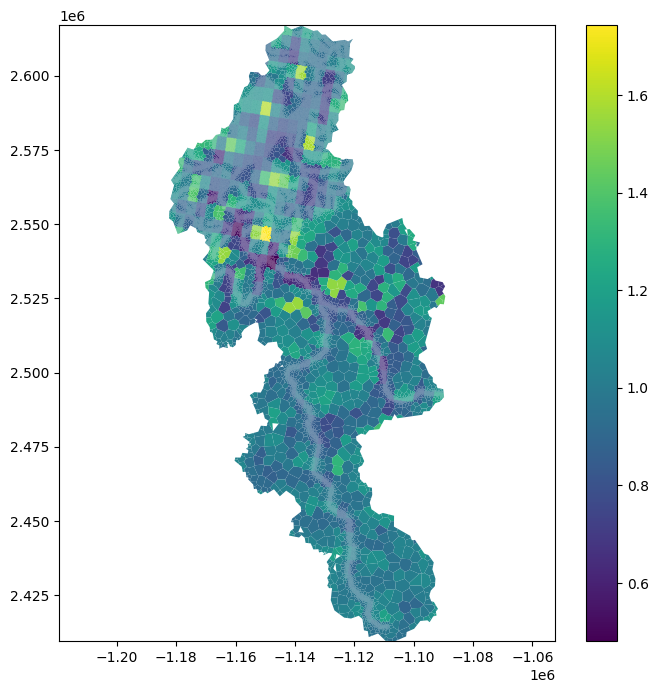

In [86]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=new_params._flopygrid, ax=ax)
pc = pmv.plot_array(new_params.parameters.rain_adj.values)
fig.colorbar(pc, ax=ax)

And now, we can view the PRMS Data Object with meteorology "station" data (the second entry in the returned tuple).

In [87]:
met_data.data_df

,Year,Month,Day,Hour,Minute,Second,tmax_0,tmax_1,tmax_2,tmax_3,...,precip_95,precip_96,precip_97,precip_98,precip_99,precip_100,precip_101,precip_102,precip_103,Date
0,1979,1,1,0,0,0,-17.527771,-17.505548,-16.427774,-16.227774,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1979-01-01
1,1979,1,2,0,0,0,-10.983327,-11.116665,-10.227773,-10.172217,...,1.344445,1.077778,0.433333,0.233333,0.077778,0.677778,0.122222,0.000000,0.000000,1979-01-02
2,1979,1,3,0,0,0,-8.927775,-8.883327,-7.794440,-7.961103,...,7.744445,6.955557,6.544445,5.933333,5.666667,11.277778,10.711111,6.066668,5.322222,1979-01-03
3,1979,1,4,0,0,0,-13.249990,-13.216658,-12.116658,-12.005550,...,6.044445,7.377778,9.788889,12.555555,11.988890,3.877778,6.655556,13.044445,11.488890,1979-01-04
4,1979,1,5,0,0,0,-14.449988,-13.983327,-12.438887,-11.372216,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1979-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16888,2025,3,28,0,0,0,10.627784,10.805559,13.183332,15.083337,...,0.322222,0.655556,0.866667,1.144444,0.622222,1.066667,1.188889,0.866667,0.455556,2025-03-28
16889,2025,3,29,0,0,0,2.561113,3.194455,4.961117,5.016673,...,1.100000,1.833333,2.400000,2.500000,2.744445,2.088889,1.922222,1.611111,1.577778,2025-03-29
16890,2025,3,30,0,0,0,0.161119,0.227783,1.183339,0.938897,...,4.755556,5.411111,4.766666,4.555555,4.411111,4.422222,3.911111,3.522222,3.833333,2025-03-30
16891,2025,3,31,0,0,0,4.283339,4.238905,3.861111,3.105557,...,7.111111,7.522223,7.388889,6.888889,5.644444,7.166667,7.177778,7.522223,6.644444,2025-03-31


## Land Cover, Soils, and Canopy Parameters from Landfire, NLCD, and SSURGO

We will now map a number of the other required PRMS paramters estimated from existing landscape raster data.

Load in Raster datasets - Landfire vegetation type, Landfire vegetation cover, NLCD impervious layer, and soil parameters derived from SSURGO (awc, ksat, sand %, and clay %).

In [88]:
lf_vegtype_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/LANDFIRE/LF2023_EVT_240_CONUS/Tif/LC23_EVT_240.tif')
lf_cover_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/LANDFIRE/LF2023_EVC_240_CONUS/Tif/LC23_EVC_240.tif')
nlcdimperv_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/NLCD/nlcd_2019_impervious_l48_20210604/nlcd_2019_impervious.tif')
awc_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/awc_huc6_MT_intersect_dissolve_7MAR2022.tif')
ksat_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/ksat_huc6_MT_intersect_dissolve_7MAR2022.tif')
sand_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/sand_huc6_MT_intersect_dissolve_7MAR2022.tif')
clay_pth = Path('D:/Spatial_Data/Statewide_Data/Raster/montana_prms_raw_rasters/clay_huc6_MT_intersect_dissolve_7MAR2022.tif')

Perform the necessary conversions and scaling of the rasters.

In [89]:
lf_vtype = load_raster_window(basin, lf_vegtype_pth, output='xarray')
lf_vtype.name = 'vegetation_type'
lf_cov = load_raster_window(basin, lf_cover_pth, output='xarray')
lf_cov.name = 'vegetation_cover'
nlcdimperv = load_raster_window(basin, nlcdimperv_pth, output='xarray')
nlcdimperv.name = 'impervious_fraction'
# as a proportion
nlcdimperv = nlcdimperv / 100
awc = load_raster_window(basin, awc_pth, output='xarray')
awc.name = 'awc'
# awc is a fraction units don't matter SSURGO states cm/cm
# wasn't sure what the scale factor was but comparing this data to Web Soil Survey, /100 provides matching fractions
awc = awc / 100
ksat = load_raster_window(basin, ksat_pth, output='xarray')
ksat.name = 'ksat'
ksat = ksat / 10000
# ksat must be in inches/day - convert from micrometer/second
ksat = ksat * 86400.0 / 25400.0
clay = load_raster_window(basin, clay_pth, output='xarray')
clay.name = 'clay'
clay = clay / 10000
sand= load_raster_window(basin, sand_pth, output='xarray')
sand.name = 'sand'
sand = sand / 10000

Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...
Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...
Geometry and raster CRS do not match, reprojecting geometry to match raster dataset...


Start a new Parameter Object to hold soil, canopy, runoff, and drainage parameters.

In [39]:
otherparams = pprms.PRMSParameters(grid=out_pth / 'UY_voronoi_grid.grid')

params.py:133: UserWarning: There are no parameters specified yet and or no nhru dimension to check grid. Assigning grid anyway, make sure to check any inserted parameters match the grid size.


MIHMS prep.prms has functions that assign raster based parameters while returning default values for any parameter not estimated by the input rasters. Below, we use the function to assigne paramters for the transp_tindex and interception modules of PRMS. This requires vegetation type, cover, sand content, and clay content. Parameters estimated by the rasters are mapped to the full grid dimensions. For the other default parameter values, we use the "spatial_dim" argument to specify we just want one value applied across all HRU's ('one').

In [90]:
pprms.transp_tindex_and_intercept_from_rasters(new_params, lf_vtype, lf_cov, sand, clay, spatial_dim='one')

C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1571: UserWarning: Not all geometries were returned, 16 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_vtype = calc_zonal_stats(paramob.grid, veg_type,


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1575: UserWarning: Not all geometries were returned, 16 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_vcov = calc_zonal_stats(paramob.grid, veg_cover,


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1579: UserWarning: Not all geometries were returned, 17 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_clay = calc_zonal_stats(paramob.grid, clay, stats='median', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1581: UserWarning: Not all geometries were returned, 17 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_sand = calc_zonal_stats(paramob.grid, sand, stats='median', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


Now map the soilzone and runoff parameters. Same process with a different function. Here we do not change the spatial_dim argument which defaults to the full dimensions ('nhru') and the full time dimension.

In [91]:
pprms.soilzone_and_srunoff_smidx_from_rasters(new_params, lf_vtype, awc, nlcdimperv)

C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1663: UserWarning: Not all geometries were returned, 16 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_vtype = calc_zonal_stats(paramob.grid, veg_type,


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1667: UserWarning: Not all geometries were returned, 17 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_awc = calc_zonal_stats(paramob.grid, awc, stats='median', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\src\mihms\prep\prms\params.py:1669: UserWarning: Not all geometries were returned, 20 geometries were missed during rasterize. Attempting to rasterize missed geometries...
  mod_imperv = calc_zonal_stats(paramob.grid, impervious, stats='mean', all_touched=True)


Second attempt did not return all geometries, defaulting to point locations for remaining geometries.


Add default solar radiation parameters. In this case we will map these to the full dimensions, a value for each month and each hru. The default groundwater flow parameters will eventually be changed during calibration so these are mapped to all HRU's. I attempted to use PRMS flexible parameter assignment by mapping to 'nsub' for each sub-basin, but this did not work. These paramteres will be calibrated by sub-basin in the future but will be done by assigning values to HRU's within each sub-basin.

In [92]:
pprms.ddsolrad_defaults(new_params)

In [93]:
pprms.groundwater_flow_defaults(new_params)

View the resulting dataset with all of the mapped parameters.

In [94]:
new_params.parameters

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                           ncascade: 90541, nmonths: 12, ntemp: 104,
                           nrain: 104, nssr: 46199, ngw: 46199)
Coordinates:
  * nrain                 (nrain) int32 0 1 2 3 4 5 6 ... 98 99 100 101 102 103
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nmonths,
                                ntemp, nssr, ngw
Data variables: (12/90)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 2 17 2 17 17 16
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev              (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                    ...
    radmax                (nmonths, nhru) float64 0.8 0.8 0.8 ... 0.8 0.8 0.8
    tmax_index            (nmonths, nhru) float64 50.0 50.0 50.0 ... 50.0 50.0
    gwflow_coef           (ngw) float64 0.015 0.015 0.015 ... 0.015 0.015 0.015
    gwsink_coef           (ngw) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    gwstor_min            (ngw) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    gwstor_init           (ngw) float64 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0

Again, using flopy plotting tools to view paramters mapped to the grid.

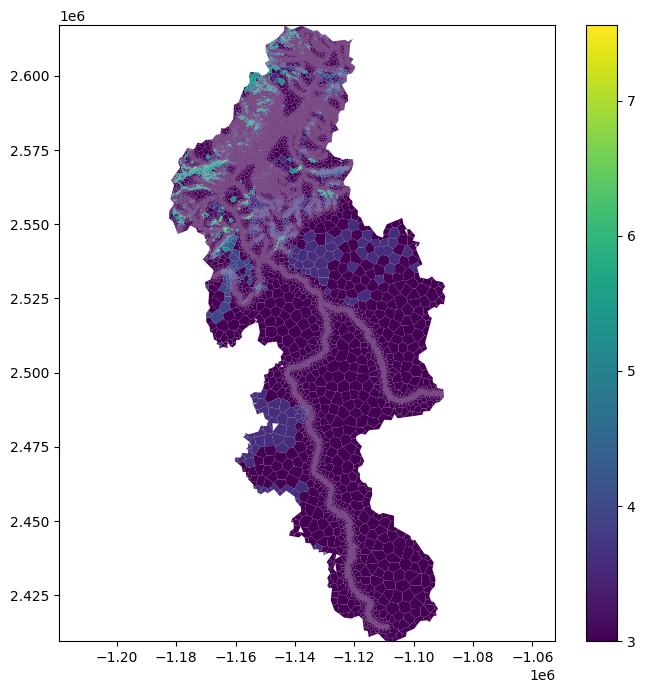

In [96]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
pmv = flopy.plot.PlotMapView(modelgrid=new_params._flopygrid, ax=ax)
pc = pmv.plot_array(new_params.parameters.soil_moist_max.values)
fig.colorbar(pc, ax=ax)

Let's go ahead and use some other MIHMS prep.prms functions to get the rest of the default parameters assigned. All that is left are the parameters associated with the 'snowcomp' module in PRMS. Again, for these defaults, we are using the full spatial dimensions ('nhru') because they will be calibrated for each sub-basin.

In [97]:
pprms.snow_comp_defaults(new_params)

We can then save this BIG, BULKY parameter file as a netcdf for easy use with xarray, or save to a PRMS parameter text file using the pygsflow methods. Here we just save it as a netcdf.

In [ ]:
otherparams.parameters.to_netcdf(out_pth / 'UY_AllOtherParams.nc')

## Create separate PRMS Files for Calibration and Static Parameters

This is a list of the PRMS parameters commonly used for calibration (see Markstrom et al. 2016). We have added a few more related to routing modules used by this particular model. We have already assigned the default parameters for most of these so now we just index the parameter datasets to contain the parameters we want to write out to each file.
- fastcoef_lin
- fastcoef_sq
- slowcoef_lin
- slowcoef_sq
- soil2gw_max
- ssr2gw_exp
- ssr2gw_rate
- soil_rechr_max_frac,
- gwflow_coef
- gwsink_coef
- gwstor_min
- pref_flow_den
- pref_flow_infil_frac
- sat_threshold
- K_coef
- x_coef
- lake_coef
- adjmix_rain
- smidx_coef
- smidx_exp
- imperv_stor_max
- snowinfil_max
- freeh2o_cap
- settle_const
- snarea_thresh

These parameters will also be used for "calibration." For this model, the first stage of calibration will be to align (not necessarily the same as calibrate ) the PRMS ddsolrad module with GridMET solar radiation corrected for terrian influence. We have already assigned defaults for these as well.
- dday_intcp
- dday_slope
- ppt_rad_adj
- radj_sppt
- radj_wppt
- radmax
- tmax_index

We will also add the ET parameter for calibration. Since most existing ET datasets are modeled anyway, this can be used to calibrate volumetric outflow from the model domain, or specifically calibrated or aligned with a desired ET dataset. We will explore aligning PRMS ET to OpenET for this model. This parameter has not been mapped so we will assign its default value to our calibration parameter obejct before writing to file.
- jh_coef

If you're not running the notebook from the start, you can load back in the parameter sets saved earlier here.

In [7]:
cascds = xr.load_dataset(out_pth / 'UY_Domain_Params.nc')
cascparams = pprms.PRMSParameters(cascds)
cascparams.grid = out_pth / 'UY_voronoi_grid.grid' 
metr = xr.load_dataset(out_pth / 'UY_meteorology_params.nc')
met_params = pprms.PRMSParameters(metr)
other = xr.load_dataset(out_pth / 'UY_AllOtherParams.nc')
otherparams = pprms.PRMSParameters(other)

params.py:206: UserWarning: The datatype of variable K_coef does not match the required datatype of the specified paramater, changing the datatype to <class 'float'>.


In [98]:
new_k = np.where(new_params.parameters['segment_type'].values == 2, 24.0, 1.0)
new_params.set_values('K_coef', new_k)

First let's make a list of all the calibration parameters we want to isolate.

In [9]:
calsel = [
    'lake_coef', 
    'K_coef', 
    'x_coef',
    'adjmix_rain', 
    'tmax_allsnow', 
    'tmax_allrain_offset',
    'potet_sublim',
    'carea_max',
    'imperv_stor_max',
    'smidx_coef',
    'smidx_exp',
    'snowinfil_max',
    'fastcoef_lin',
    'fastcoef_sq',
    'slowcoef_lin',
    'slowcoef_sq',
    'soil2gw_max',
    'ssr2gw_exp',
    'ssr2gw_rate',
    'soil_rechr_max_frac',
    'gwflow_coef',
    'gwsink_coef',
    'gwstor_min',
    'pref_flow_den',
    'pref_flow_infil_frac',
    'sat_threshold',
    'freeh2o_cap',
    'settle_const',
    'snarea_thresh',
    'dday_intcp',
    'dday_slope',
    'ppt_rad_adj',
    'radj_sppt',
    'radj_wppt',
    'radmax',
    'tmax_index'
]

Now we can use this list, and it's inverse, along with the .select_parameters() function of the PRMSParameters class to get two xarray datasets of our non-calibration parameters and calibration parameters.

In [10]:
cascparams.merge_parameters([met_params, otherparams])
staticsel = [i for i in list(cascparams.parameters.data_vars) if i not in calsel]
calibparams = cascparams.select_parameters(calsel)
allparams = cascparams.select_parameters(staticsel)

Use these Datasets to make new paramter objects.

In [11]:
calibparams = pprms.PRMSParameters(calibparams)
allparams = pprms.PRMSParameters(allparams)

Now we add the ET jh_coef paramter to our calibration parameter set.

In [99]:
new_params.add_parameter(
    'jh_coef',
    np.ones((12, len(cascparams.grid))) * 0.014,
    [12, len(cascparams.grid)],
    ['nmonths', 'nhru']
)

Again, we can save this comprehensive parameter set as a netcdf.

In [100]:
new_params.parameters.to_netcdf(out_pth / 'UY_nolake_params.nc')

## Saving Parameter and Data Files as PRMS files

Next we will save the parameter and data files as PRMS format files so that we can construct a control file for our model, and run it using pygsflow commands.

Since the MIHMS PRMSParameters class is essentially a wrapper around the equivalent pygsflow object, it's methods are available when using the class property pygsflow_param_obj. This returns the pygsflow equivalent which has a .write() method which just takes the filename as an argument.

In [101]:
new_params.write_paramfile(out_pth / 'UY_nolake_params.param')

Simple! Now for the data file.

Finally, we use the methods associated with the pygsflow PrmsData class to write out the data file in the correct format. Recalling that this object was output as the 2nd entry in a tuple from the temp_1sta_from_gridded() function....BUT! The write method in pygsflow isn't working because the master branch that is installable has not been updated to deal with a pandas deprication of 'line_termination' -> 'linetermination.'

The mihms.prep.prms.utils module has a copied function from pygsflow that does the same thing with the PrmsData object as input.

In [103]:
write_prms_datafile(met_data, out_pth / 'UYnolake_1979_2025.data')

In [104]:
met_data.data_df.to_csv(out_pth / 'UYnolake_PRMS_data.csv')

## Constructing a Control File for PRMS

The MIHMS package builds a wrapper around pygsflow control object methods so that defaults can be assigned more easily and the use of custom toml or json files are readable to create a custom control file template. Here we use just the standard control file builder. MIHMS has default builds for different domain outputs (for HRU's, segments, subbasins, etc.).

In [9]:
prmscont = pprms.StandardControl(Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'), '6.0.0', '2020-01-01', '2024-12-31', out_pth / 'UYdata.data', [out_pth / 'UY_static_params.param', out_pth / 'UY_calib_params.param'], out_pth, file_name='UY.control')

In [4]:
prmscont = pprms.SubOutControl(Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'), 
                               '6.0.0', 
                               '2020-01-01', 
                               '2024-12-31', 
                               out_pth / 'UYdata.data', 
                               [out_pth / 'UY_static_params.param', out_pth / 'UY_calib_params.param'], 
                               out_pth, 
                               file_name='UY.control')

In [10]:
prmscont = pprms.SegmentOutControl(Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'), '6.0.0', '2020-01-01', '2024-12-31', out_pth / 'UYdata.data', [out_pth / 'UY_static_params.param', out_pth / 'UY_calib_params.param'], out_pth, file_name='UY.control')

However, we can change the defaults once assinged here. In this case, we do want to change the streamflow module from the default 'strmflow' to 'muskingum_lake' for this example. We do this using the pygsflow ControlFile method .set_values().

In [13]:
prmscont.control_obj.set_values('strmflow_module', ['muskingum'])

We can see that the change worked.

In [14]:
print(prmscont.control_obj.get_record('strmflow_module'))


####
strmflow_module
1
4
muskingum
####


A property of the MIHMS Control classes is a pygsflow ControlFile object which contains the method for writing to file. We use this here to output to a PRMS readable file.

In [15]:
prmscont.save_controlfile()